#  Parallel PageRank: Algorithm Comparison Notebook

This notebook implements and benchmarks **three PageRank strategies** on a real web-crawl graph:

| Strategy | Description |
|---|---|
| **Sequential** | Single-process, single-thread |
| **Centralized Aggregation** | Workers compute chunks; driver aggregates results |
| **Distributed Reduction** | Workers compute chunks; tree-reduction merges results |

Each strategy is evaluated under **two termination policies**:
- **Fixed Iteration Count** — always runs exactly `FIXED_ITERS` iterations
- **Convergence-Based** — stops when `max_diff < tolerance`

**Metrics collected:** total time, per-iteration time, speedup vs sequential, convergence iteration, communication overhead.

---
**Environment:** Kaggle Notebook · 4 physical cores / 8 logical processors  
**Graph input:** `crawl_graph.json` — add it via *Add Data* in Kaggle before running.

## 0 · Environment Setup

In [60]:
import subprocess, sys

def install_package(package: str) -> None:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', package, '--quiet'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"✓ '{package}' installed successfully.")
    else:
        print(f"✗ Failed to install '{package}':")
        print(result.stderr[-500:])

for pkg in ['ray', 'jinja2', 'nbformat']:
    install_package(pkg)

✓ 'ray' installed successfully.
✓ 'jinja2' installed successfully.
✓ 'nbformat' installed successfully.


In [61]:
import ray
import json
import time
import os
import gc
import tempfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from collections import defaultdict

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('All imports OK.')
print(f'NumPy {np.__version__}  |  Pandas {pd.__version__}  |  Ray {ray.__version__}')


import os
os.makedirs('outputs', exist_ok=True)
run_num = 1
while os.path.exists(f'outputs/run{run_num}'):
    run_num += 1
base_out_dir = f'outputs/run{run_num}'
img_out_dir = f'{base_out_dir}/images'
os.makedirs(img_out_dir, exist_ok=True)
print(f'Output dirs initialized: {img_out_dir} and {base_out_dir}/{run_num}.txt')


All imports OK.
NumPy 2.4.3  |  Pandas 3.0.1  |  Ray 2.54.0
Output dirs initialized: outputs/run5/images and outputs/run5/5.txt


## 1 · Hyperparameters

Tuned for a 4-core / 8-logical-processor Kaggle instance.

In [62]:
# ── Graph ──────────────────────────────────────────────────────────────
GRAPH_FILE      = 'crawl_graph_2.json'   # Kaggle dataset path
# Fallback: if running locally, adjust the path below
if not os.path.exists(GRAPH_FILE):
    GRAPH_FILE  = 'crawl_graph_1.json'

# ── PageRank ───────────────────────────────────────────────────────────
DAMPING         = 0.85          # standard damping factor
TOLERANCE       = 1e-6          # convergence threshold (L∞ norm)
MAX_ITERS       = 100           # safety cap for convergence mode
FIXED_ITERS     = 25            # fixed iteration count comparison

# ── Parallelism ────────────────────────────────────────────────────────
# 4 workers = 1 worker per physical core; leaves headroom for Ray overhead
NUM_WORKERS     = 12

print(f'Graph file   : {GRAPH_FILE}')
print(f'Damping      : {DAMPING}')
print(f'Tolerance    : {TOLERANCE}')
print(f'Max iters    : {MAX_ITERS}  (convergence mode)')
print(f'Fixed iters  : {FIXED_ITERS}')
print(f'Workers      : {NUM_WORKERS}')

Graph file   : crawl_graph_2.json
Damping      : 0.85
Tolerance    : 1e-06
Max iters    : 100  (convergence mode)
Fixed iters  : 25
Workers      : 12


## 2 · Shared Graph Utilities

In [63]:
def load_graph(graph_file):
    print(f'Loading graph from {graph_file} ...')
    with open(graph_file, 'r') as f:
        graph = json.load(f)
    print(f'  Raw graph loaded: {len(graph):,} source nodes.')
    return graph


def build_index_maps(graph):
    """Assign each unique node a stable integer index."""
    nodes = set(graph.keys())
    for dests in graph.values():
        nodes.update(dests)
    node_to_idx = {node: i for i, node in enumerate(sorted(nodes))}
    idx_to_node = {i: node for node, i in node_to_idx.items()}
    return node_to_idx, idx_to_node


def build_csr(graph, node_to_idx):
    """
    Build inbound CSR (Compressed Sparse Row) and outbound-count array.

    Returns
    -------
    indptr    : shape (N+1,)  — slice boundaries for inbound neighbours
    indices   : shape (E,)    — concatenated inbound neighbour index lists
    out_counts: shape (N,)    — outbound link count per node
    """
    N = len(node_to_idx)

    out_counts = np.zeros(N, dtype=np.int32)
    for source, dests in graph.items():
        out_counts[node_to_idx[source]] = len(dests)

    indegree = np.zeros(N, dtype=np.int32)
    for source, dests in graph.items():
        for dest in dests:
            indegree[node_to_idx[dest]] += 1

    indptr = np.zeros(N + 1, dtype=np.int32)
    np.cumsum(indegree, out=indptr[1:])

    indices  = np.empty(indptr[N], dtype=np.int32)
    fill_pos = indptr[:-1].copy()
    for source, dests in graph.items():
        src_idx = node_to_idx[source]
        for dest in dests:
            dst_idx = node_to_idx[dest]
            indices[fill_pos[dst_idx]] = src_idx
            fill_pos[dst_idx] += 1

    return indptr, indices, out_counts


def prepare_shared_structures(graph_file):
    """
    Load graph once, build CSR once, return everything needed
    by all three algorithms so we don't repeat I/O.
    """
    graph = load_graph(graph_file)

    print('  Building index maps...')
    node_to_idx, idx_to_node = build_index_maps(graph)
    N = len(node_to_idx)
    print(f'  Total unique nodes: {N:,}')

    print('  Building CSR structures...')
    t0 = time.time()
    indptr, indices, out_counts = build_csr(graph, node_to_idx)
    print(f'  CSR built in {time.time() - t0:.2f}s')
    print(f'  indptr  {indptr.nbytes/1e6:.1f} MB | '
          f'indices {indices.nbytes/1e6:.1f} MB | '
          f'out_counts {out_counts.nbytes/1e6:.1f} MB')

    del graph; gc.collect()
    print('  Raw graph freed.')

    total_edges = int(indptr[N])
    print(f'  Total directed edges: {total_edges:,}')

    return N, idx_to_node, indptr, indices, out_counts


print('Graph utilities defined.')

Graph utilities defined.


In [64]:
# ── Load and build CSR once — shared across all three algorithms ────────
N, idx_to_node, indptr, indices, out_counts = prepare_shared_structures(GRAPH_FILE)

Loading graph from crawl_graph_2.json ...
  Raw graph loaded: 18,888 source nodes.
  Building index maps...
  Total unique nodes: 323,223
  Building CSR structures...
  CSR built in 1.51s
  indptr  1.3 MB | indices 5.2 MB | out_counts 1.3 MB
  Raw graph freed.
  Total directed edges: 1,300,951


## 3 · Graph Overview

In [65]:
# Basic graph statistics
total_edges = int(indptr[N])
in_degrees  = np.diff(indptr)          # indptr[i+1] - indptr[i]
out_degrees = out_counts.astype(np.int64)

dangling_nodes = int(np.sum(out_counts == 0))   # nodes with no outbound links
sink_nodes     = int(np.sum(in_degrees  == 0))  # nodes with no inbound links

stats = {
    'Total Nodes'          : f'{N:,}',
    'Total Directed Edges' : f'{total_edges:,}',
    'Avg Out-Degree'       : f'{out_degrees.mean():.2f}',
    'Max Out-Degree'       : f'{out_degrees.max():,}',
    'Avg In-Degree'        : f'{in_degrees.mean():.2f}',
    'Max In-Degree'        : f'{in_degrees.max():,}',
    'Dangling Nodes (out=0)': f'{dangling_nodes:,}',
    'Sink Nodes (in=0)'    : f'{sink_nodes:,}',
    'Graph Density'        : f'{total_edges / (N * (N-1)):.2e}',
}

df_stats = pd.DataFrame(stats.items(), columns=['Property', 'Value'])
print('\n── Graph Statistics ──')
print(df_stats.to_string(index=False))


── Graph Statistics ──
              Property     Value
           Total Nodes   323,223
  Total Directed Edges 1,300,951
        Avg Out-Degree      4.02
        Max Out-Degree    15,464
         Avg In-Degree      4.02
         Max In-Degree     1,612
Dangling Nodes (out=0)   304,335
     Sink Nodes (in=0)        26
         Graph Density  1.25e-05


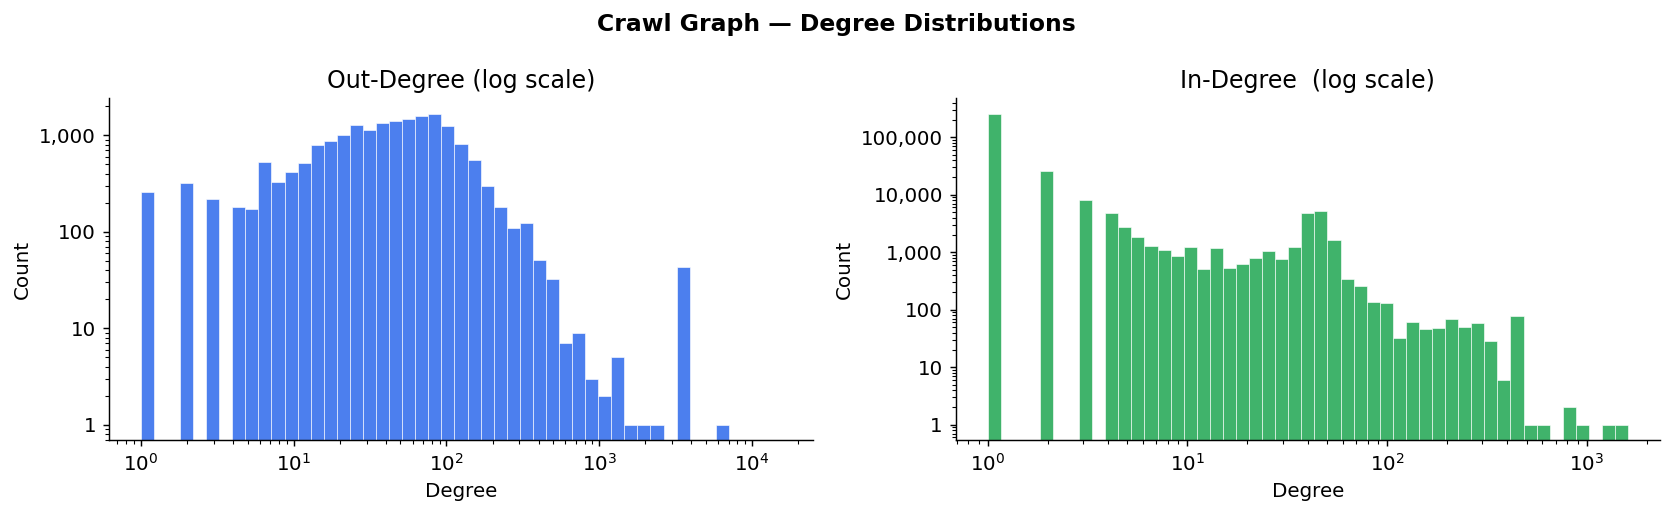

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Crawl Graph — Degree Distributions', fontsize=13, fontweight='bold')

for ax, deg, label, color in [
    (axes[0], out_degrees[out_degrees > 0], 'Out-Degree (log scale)', '#2563EB'),
    (axes[1], in_degrees [in_degrees  > 0], 'In-Degree  (log scale)', '#16A34A'),
]:
    bins = np.logspace(0, np.log10(max(deg.max(), 2)), 50)
    ax.hist(deg, bins=bins, color=color, alpha=0.82, edgecolor='white', linewidth=0.4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(f'{img_out_dir}/degree_distribution.png', bbox_inches='tight')
plt.show()

## 4 · Algorithm Implementations

### 4.1 Sequential PageRank

In [67]:
def run_sequential_pagerank(
    N, idx_to_node, indptr, indices, out_counts,
    d=0.85, max_iterations=100, tolerance=1e-6,
    fixed_iters=None
):
    """
    Single-process iterative PageRank.

    Parameters
    ----------
    fixed_iters : int or None
        If given, run exactly this many iterations (ignore tolerance).
        If None, run until convergence.

    Returns
    -------
    dict with keys: 'ranks', 'iter_times', 'iter_diffs',
                    'total_time', 'converged_at'
    """
    mode        = 'fixed' if fixed_iters else 'convergence'
    n_iters     = fixed_iters if fixed_iters else max_iterations
    print(f'[Sequential | {mode}] Starting — {n_iters} max iteration(s)...')

    pagerank  = np.full(N, 1.0 / N, dtype='float64')
    new_ranks = np.empty(N, dtype='float64')

    iter_times = []
    iter_diffs = []
    converged_at = None

    start_time = time.perf_counter()

    for iteration in range(n_iters):
        t_iter_start = time.perf_counter()

        for node in range(N):
            inbound = indices[indptr[node]: indptr[node + 1]]
            if inbound.size > 0:
                rank_sum = np.sum(pagerank[inbound] / np.maximum(out_counts[inbound], 1))
            else:
                rank_sum = 0.0
            new_ranks[node] = (1 - d) / N + d * rank_sum

        max_diff = float(np.max(np.abs(new_ranks - pagerank)))
        pagerank, new_ranks = new_ranks, pagerank

        t_iter = time.perf_counter() - t_iter_start
        iter_times.append(t_iter)
        iter_diffs.append(max_diff)

        if (iteration + 1) % 5 == 0 or iteration == 0:
            print(f'  iter {iteration+1:3d}  max_diff={max_diff:.2e}  '
                  f'iter_time={t_iter:.3f}s')

        if fixed_iters is None and max_diff < tolerance:
            converged_at = iteration + 1
            print(f'  → Converged at iteration {converged_at}.')
            break

    total_time = time.perf_counter() - start_time
    print(f'[Sequential | {mode}] Done in {total_time:.2f}s.\n')

    final_ranks = {idx_to_node[i]: float(pagerank[i]) for i in range(N)}
    return {
        'ranks'       : final_ranks,
        'iter_times'  : iter_times,
        'iter_diffs'  : iter_diffs,
        'total_time'  : total_time,
        'converged_at': converged_at or len(iter_times),
        'mode'        : mode,
    }


print('Sequential PageRank defined.')

Sequential PageRank defined.


### 4.2 Centralized Aggregation (Ray)

In [68]:
@ray.remote
def _ca_compute_chunk(node_chunk, mmap_path, indptr_ref, indices_ref, out_ref, N, d):
    """Worker: compute new ranks for a node chunk from shared-memory CSR."""
    import numpy as np
    pagerank   = np.memmap(mmap_path, dtype='float64', mode='r', shape=(N,))
    indptr     = indptr_ref
    indices    = indices_ref
    out_counts = out_ref

    new_ranks      = np.empty(len(node_chunk), dtype='float64')
    local_max_diff = 0.0

    for i, node in enumerate(node_chunk):
        inbound = indices[indptr[node]: indptr[node + 1]]
        rank_sum = (np.sum(pagerank[inbound] / np.maximum(out_counts[inbound], 1))
                    if inbound.size > 0 else 0.0)
        nr  = (1 - d) / N + d * rank_sum
        new_ranks[i] = nr
        diff = abs(nr - pagerank[node])
        if diff > local_max_diff:
            local_max_diff = diff

    del pagerank
    return node_chunk, new_ranks, local_max_diff


def run_centralized_aggregation(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=4, d=0.85, max_iterations=100, tolerance=1e-6,
    fixed_iters=None
):
    """
    Parallel PageRank — driver collects all worker results each iteration.

    Communication cost: O(num_workers) ray.get() calls + O(N) write-back per iter.
    """
    mode   = 'fixed' if fixed_iters else 'convergence'
    n_iters = fixed_iters if fixed_iters else max_iterations
    print(f'[Centralized | {mode}] Starting — {num_workers} workers, {n_iters} max iter...')

    # Push CSR into Ray object store (zero-copy reads from workers)
    indptr_ref   = ray.put(indptr)
    indices_ref  = ray.put(indices)
    out_ref      = ray.put(out_counts)

    # Memory-mapped pagerank vector (shared file, workers read via mmap)
    tmp_dir   = tempfile.mkdtemp()
    mmap_path = os.path.join(tmp_dir, 'pagerank.dat')
    pm        = np.memmap(mmap_path, dtype='float64', mode='w+', shape=(N,))
    pm[:]     = 1.0 / N;  pm.flush();  del pm

    chunk_size  = (N + num_workers - 1) // num_workers
    all_idx     = list(range(N))
    node_chunks = [all_idx[i * chunk_size:(i + 1) * chunk_size]
                   for i in range(num_workers)]

    iter_times   = []
    iter_diffs   = []
    comm_times   = []   # time spent in ray.get() — pure communication overhead
    converged_at = None

    start_time = time.perf_counter()

    for iteration in range(n_iters):
        t_iter_start = time.perf_counter()

        # ── Dispatch ──────────────────────────────────────────────────
        futures = [
            _ca_compute_chunk.remote(
                chunk, mmap_path, indptr_ref, indices_ref, out_ref, N, d
            )
            for chunk in node_chunks
        ]

        # ── Centralized collect (communication cost) ──────────────────
        t_comm_start = time.perf_counter()
        results      = ray.get(futures)
        comm_time    = time.perf_counter() - t_comm_start
        comm_times.append(comm_time)

        # ── Aggregate & write back ────────────────────────────────────
        pm              = np.memmap(mmap_path, dtype='float64', mode='r+', shape=(N,))
        global_max_diff = 0.0
        for node_idx, new_ranks, wmax in results:
            pm[node_idx] = new_ranks
            if wmax > global_max_diff:
                global_max_diff = wmax
        pm.flush();  del pm;  gc.collect()

        t_iter = time.perf_counter() - t_iter_start
        iter_times.append(t_iter)
        iter_diffs.append(global_max_diff)

        if (iteration + 1) % 5 == 0 or iteration == 0:
            print(f'  iter {iteration+1:3d}  max_diff={global_max_diff:.2e}  '
                  f'iter_time={t_iter:.3f}s  comm={comm_time:.3f}s')

        if fixed_iters is None and global_max_diff < tolerance:
            converged_at = iteration + 1
            print(f'  → Converged at iteration {converged_at}.')
            break

    total_time = time.perf_counter() - start_time
    print(f'[Centralized | {mode}] Done in {total_time:.2f}s.\n')

    # Read final ranks
    final_mmap  = np.memmap(mmap_path, dtype='float64', mode='r', shape=(N,))
    final_ranks = {idx_to_node[i]: float(final_mmap[i]) for i in range(N)}
    del final_mmap
    os.remove(mmap_path);  os.rmdir(tmp_dir)

    return {
        'ranks'       : final_ranks,
        'iter_times'  : iter_times,
        'iter_diffs'  : iter_diffs,
        'comm_times'  : comm_times,
        'total_time'  : total_time,
        'converged_at': converged_at or len(iter_times),
        'mode'        : mode,
    }


print('Centralized Aggregation PageRank defined.')

Centralized Aggregation PageRank defined.


### 4.3 Distributed Reduction (Ray)

In [69]:
@ray.remote
def _dr_compute_chunk(node_chunk, mmap_path, indptr_ref, indices_ref, out_ref, N, d):
    """Identical compute worker — reused for distributed reduction."""
    import numpy as np
    pagerank   = np.memmap(mmap_path, dtype='float64', mode='r', shape=(N,))
    indptr     = indptr_ref
    indices    = indices_ref
    out_counts = out_ref

    new_ranks      = np.empty(len(node_chunk), dtype='float64')
    local_max_diff = 0.0

    for i, node in enumerate(node_chunk):
        inbound = indices[indptr[node]: indptr[node + 1]]
        rank_sum = (np.sum(pagerank[inbound] / np.maximum(out_counts[inbound], 1))
                    if inbound.size > 0 else 0.0)
        nr = (1 - d) / N + d * rank_sum
        new_ranks[i] = nr
        diff = abs(nr - pagerank[node])
        if diff > local_max_diff:
            local_max_diff = diff

    del pagerank
    return node_chunk, new_ranks, local_max_diff


@ray.remote
def _reduce_pair(result_a, result_b):
    """
    Tree-reduction step: merge two worker results in a Ray task.
    The driver never touches intermediate arrays — they stay in the
    object store and are merged here on a worker process.

    Round example (8 workers):
      r1: (0+1),(2+3),(4+5),(6+7) → 4
      r2: (01+23),(45+67)         → 2
      r3: (0123+4567)             → 1  ← single ray.get()
    """
    import numpy as np
    idx_a, ranks_a, diff_a = result_a
    idx_b, ranks_b, diff_b = result_b
    return (
        np.concatenate([idx_a, idx_b]),
        np.concatenate([ranks_a, ranks_b]),
        max(diff_a, diff_b),
    )


def run_distributed_reduction(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=4, d=0.85, max_iterations=100, tolerance=1e-6,
    fixed_iters=None
):
    """
    Parallel PageRank — tree reduction merges results without driver involvement.

    Communication cost: O(log num_workers) reduction rounds,
    only 1 ray.get() per iteration (the merged root).
    """
    mode    = 'fixed' if fixed_iters else 'convergence'
    n_iters = fixed_iters if fixed_iters else max_iterations
    print(f'[Distributed | {mode}] Starting — {num_workers} workers, '
          f'tree depth {int(np.ceil(np.log2(num_workers+1)))} rounds...')

    indptr_ref = ray.put(indptr)
    indices_ref= ray.put(indices)
    out_ref    = ray.put(out_counts)

    tmp_dir   = tempfile.mkdtemp()
    mmap_path = os.path.join(tmp_dir, 'pagerank.dat')
    pm        = np.memmap(mmap_path, dtype='float64', mode='w+', shape=(N,))
    pm[:]     = 1.0 / N;  pm.flush();  del pm

    chunk_size  = (N + num_workers - 1) // num_workers
    all_idx     = list(range(N))
    node_chunks = [all_idx[i * chunk_size:(i + 1) * chunk_size]
                   for i in range(num_workers)]

    iter_times    = []
    iter_diffs    = []
    reduce_rounds = []   # number of tree-reduction rounds per iteration
    converged_at  = None

    start_time = time.perf_counter()

    for iteration in range(n_iters):
        t_iter_start = time.perf_counter()

        # ── Dispatch compute workers ───────────────────────────────────
        futures = [
            _dr_compute_chunk.remote(
                chunk, mmap_path, indptr_ref, indices_ref, out_ref, N, d
            )
            for chunk in node_chunks
        ]

        # ── Tree reduction (all in Ray — driver waits only at root) ───
        rounds = 0
        while len(futures) > 1:
            next_round = []
            for i in range(0, len(futures), 2):
                if i + 1 < len(futures):
                    next_round.append(_reduce_pair.remote(futures[i], futures[i + 1]))
                else:
                    next_round.append(futures[i])   # odd element passes through
            futures = next_round
            rounds += 1
        reduce_rounds.append(rounds)

        # Single get — only the merged root result crosses the object store
        all_node_idx, all_new_ranks, global_max_diff = ray.get(futures[0])

        # Write back to mmap
        pm = np.memmap(mmap_path, dtype='float64', mode='r+', shape=(N,))
        pm[all_node_idx] = all_new_ranks
        pm.flush();  del pm;  gc.collect()

        t_iter = time.perf_counter() - t_iter_start
        iter_times.append(t_iter)
        iter_diffs.append(global_max_diff)

        if (iteration + 1) % 5 == 0 or iteration == 0:
            print(f'  iter {iteration+1:3d}  max_diff={global_max_diff:.2e}  '
                  f'iter_time={t_iter:.3f}s  reduce_rounds={rounds}')

        if fixed_iters is None and global_max_diff < tolerance:
            converged_at = iteration + 1
            print(f'  → Converged at iteration {converged_at}.')
            break

    total_time = time.perf_counter() - start_time
    print(f'[Distributed | {mode}] Done in {total_time:.2f}s.\n')

    final_mmap  = np.memmap(mmap_path, dtype='float64', mode='r', shape=(N,))
    final_ranks = {idx_to_node[i]: float(final_mmap[i]) for i in range(N)}
    del final_mmap
    os.remove(mmap_path);  os.rmdir(tmp_dir)

    return {
        'ranks'          : final_ranks,
        'iter_times'     : iter_times,
        'iter_diffs'     : iter_diffs,
        'reduce_rounds'  : reduce_rounds,
        'total_time'     : total_time,
        'converged_at'   : converged_at or len(iter_times),
        'mode'           : mode,
    }


print('Distributed Reduction PageRank defined.')

Distributed Reduction PageRank defined.


## 5 · Run All Experiments

In [70]:
# Initialise Ray (safe to call multiple times)
if not ray.is_initialized():
    ray.init(num_cpus=NUM_WORKERS, ignore_reinit_error=True)
    
print(f'Ray initialised | CPUs: {ray.available_resources().get("CPU", "?")}')

Ray initialised | CPUs: 12.0


In [71]:
# ── 5.1  Sequential — both modes ───────────────────────────────────────
print('=' * 60)
print('EXPERIMENT 1/6 · Sequential | Fixed Iterations')
print('=' * 60)
seq_fixed = run_sequential_pagerank(
    N, idx_to_node, indptr, indices, out_counts,
    d=DAMPING, max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=FIXED_ITERS
)

print('=' * 60)
print('EXPERIMENT 2/6 · Sequential | Convergence')
print('=' * 60)
seq_conv = run_sequential_pagerank(
    N, idx_to_node, indptr, indices, out_counts,
    d=DAMPING, max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=None
)

EXPERIMENT 1/6 · Sequential | Fixed Iterations
[Sequential | fixed] Starting — 25 max iteration(s)...


  iter   1  max_diff=1.05e-04  iter_time=3.772s
  iter   5  max_diff=3.01e-06  iter_time=2.672s
  iter  10  max_diff=1.23e-07  iter_time=2.997s
  iter  15  max_diff=1.95e-08  iter_time=2.604s
  iter  20  max_diff=6.36e-09  iter_time=2.570s
  iter  25  max_diff=2.63e-09  iter_time=2.625s
[Sequential | fixed] Done in 67.24s.

EXPERIMENT 2/6 · Sequential | Convergence
[Sequential | convergence] Starting — 100 max iteration(s)...
  iter   1  max_diff=1.05e-04  iter_time=2.618s
  iter   5  max_diff=3.01e-06  iter_time=2.538s
  → Converged at iteration 7.
[Sequential | convergence] Done in 17.91s.



In [72]:
# ── 5.2  Centralized Aggregation — both modes ──────────────────────────
print('=' * 60)
print('EXPERIMENT 3/6 · Centralized Aggregation | Fixed Iterations')
print('=' * 60)
ca_fixed = run_centralized_aggregation(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=NUM_WORKERS, d=DAMPING,
    max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=FIXED_ITERS
)

print('=' * 60)
print('EXPERIMENT 4/6 · Centralized Aggregation | Convergence')
print('=' * 60)
ca_conv = run_centralized_aggregation(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=NUM_WORKERS, d=DAMPING,
    max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=None
)

EXPERIMENT 3/6 · Centralized Aggregation | Fixed Iterations
[Centralized | fixed] Starting — 12 workers, 25 max iter...
  iter   1  max_diff=1.05e-04  iter_time=5.046s  comm=4.498s
  iter   5  max_diff=3.01e-06  iter_time=1.242s  comm=0.832s
  iter  10  max_diff=1.23e-07  iter_time=0.925s  comm=0.617s
  iter  15  max_diff=1.95e-08  iter_time=1.027s  comm=0.662s
  iter  20  max_diff=6.36e-09  iter_time=0.922s  comm=0.644s
  iter  25  max_diff=2.63e-09  iter_time=1.149s  comm=0.776s
[Centralized | fixed] Done in 30.97s.

EXPERIMENT 4/6 · Centralized Aggregation | Convergence
[Centralized | convergence] Starting — 12 workers, 100 max iter...
  iter   1  max_diff=1.05e-04  iter_time=1.120s  comm=0.709s
  iter   5  max_diff=3.01e-06  iter_time=1.074s  comm=0.706s
  → Converged at iteration 7.
[Centralized | convergence] Done in 7.64s.



In [73]:
# ── 5.3  Distributed Reduction — both modes ────────────────────────────
print('=' * 60)
print('EXPERIMENT 5/6 · Distributed Reduction | Fixed Iterations')
print('=' * 60)
dr_fixed = run_distributed_reduction(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=NUM_WORKERS, d=DAMPING,
    max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=FIXED_ITERS
)

print('=' * 60)
print('EXPERIMENT 6/6 · Distributed Reduction | Convergence')
print('=' * 60)
dr_conv = run_distributed_reduction(
    N, idx_to_node, indptr, indices, out_counts,
    num_workers=NUM_WORKERS, d=DAMPING,
    max_iterations=MAX_ITERS, tolerance=TOLERANCE,
    fixed_iters=None
)

print('All experiments complete.')

EXPERIMENT 5/6 · Distributed Reduction | Fixed Iterations
[Distributed | fixed] Starting — 12 workers, tree depth 4 rounds...
  iter   1  max_diff=1.05e-04  iter_time=1.153s  reduce_rounds=4
  iter   5  max_diff=3.01e-06  iter_time=1.073s  reduce_rounds=4
  iter  10  max_diff=1.23e-07  iter_time=1.071s  reduce_rounds=4
  iter  15  max_diff=1.95e-08  iter_time=1.094s  reduce_rounds=4
  iter  20  max_diff=6.36e-09  iter_time=0.954s  reduce_rounds=4
  iter  25  max_diff=2.63e-09  iter_time=0.999s  reduce_rounds=4
[Distributed | fixed] Done in 29.93s.

EXPERIMENT 6/6 · Distributed Reduction | Convergence
[Distributed | convergence] Starting — 12 workers, tree depth 4 rounds...
  iter   1  max_diff=1.05e-04  iter_time=0.964s  reduce_rounds=4
  iter   5  max_diff=3.01e-06  iter_time=1.023s  reduce_rounds=4
  → Converged at iteration 7.
[Distributed | convergence] Done in 7.57s.

All experiments complete.


## 6 · Results & Metrics

In [74]:
# ── Build summary table ────────────────────────────────────────────────
results_map = {
    ('Sequential',            'Fixed')      : seq_fixed,
    ('Sequential',            'Convergence'): seq_conv,
    ('Centralized Aggregation','Fixed')     : ca_fixed,
    ('Centralized Aggregation','Convergence'): ca_conv,
    ('Distributed Reduction', 'Fixed')      : dr_fixed,
    ('Distributed Reduction', 'Convergence'): dr_conv,
}

# Sequential convergence time is our baseline for speedup
seq_conv_time  = seq_conv['total_time']
seq_fixed_time = seq_fixed['total_time']

rows = []
for (algo, mode), res in results_map.items():
    iters       = len(res['iter_times'])
    total       = res['total_time']
    avg_iter    = np.mean(res['iter_times'])
    baseline    = seq_fixed_time if mode == 'Fixed' else seq_conv_time
    speedup     = baseline / total
    comm_pct    = 0.0
    if 'comm_times' in res:
        comm_pct = 100 * np.sum(res['comm_times']) / total

    rows.append({
        'Algorithm'        : algo,
        'Mode'             : mode,
        'Iterations Run'   : iters,
        'Converged At'     : res['converged_at'],
        'Total Time (s)'   : round(total, 3),
        'Avg Iter Time (s)': round(avg_iter, 4),
        'Speedup vs Seq'   : round(speedup, 3),
        'Comm Overhead %'  : round(comm_pct, 1),
        'Final Max Diff'   : f"{res['iter_diffs'][-1]:.2e}",
    })

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['Algorithm', 'Mode'])

print('\n' + '─' * 80)
print('                  PAGERANK BENCHMARK SUMMARY')
print('─' * 80)
print(df_summary.to_string())
print('─' * 80)

# Also display nicely styled
df_summary.style \
    .background_gradient(subset=['Total Time (s)'], cmap='RdYlGn_r') \
    .background_gradient(subset=['Speedup vs Seq'],  cmap='RdYlGn') \
    .background_gradient(subset=['Comm Overhead %'], cmap='Oranges') \
    .format({'Speedup vs Seq': '{:.3f}×'}) \
    .set_caption('PageRank Benchmark — Kaggle (4 cores / 8 logical)')


────────────────────────────────────────────────────────────────────────────────
                  PAGERANK BENCHMARK SUMMARY
────────────────────────────────────────────────────────────────────────────────
                                     Iterations Run  Converged At  Total Time (s)  Avg Iter Time (s)  Speedup vs Seq  Comm Overhead % Final Max Diff
Algorithm               Mode                                                                                                                        
Sequential              Fixed                    25            25          67.244             2.6869           1.000              0.0       2.63e-09
                        Convergence               7             7          17.908             2.5582           1.000              0.0       6.94e-07
Centralized Aggregation Fixed                    25            25          30.975             1.2389           2.171             68.8       2.63e-09
                        Convergence            

In [75]:
# ── Top 10 pages by PageRank (convergence mode) ────────────────────────
print('\n── Top 10 Pages (Convergence-Based, Sequential) ──')
top10_seq = sorted(seq_conv['ranks'].items(), key=lambda x: x[1], reverse=True)[:10]
df_top10 = pd.DataFrame(top10_seq, columns=['URL', 'PageRank Score'])
df_top10.index += 1
df_top10['PageRank Score'] = df_top10['PageRank Score'].map('{:.8f}'.format)
print(df_top10.to_string())


── Top 10 Pages (Convergence-Based, Sequential) ──
                                           URL PageRank Score
1   https://play.google.com/store/apps/details     0.00003033
2                          https://atproto.com     0.00002049
3          https://policies.google.com/privacy     0.00002005
4                          https://bsky.social     0.00001972
5       https://facebook.com/sharer/sharer.php     0.00001639
6             https://twitter.com/intent/tweet     0.00001500
7            https://policies.google.com/terms     0.00001474
8                         https://af.imgbb.com     0.00001442
9                         https://am.imgbb.com     0.00001442
10                       https://api.imgbb.com     0.00001442


## 7 · Visualisations

### 7.1 Total Execution Time Comparison

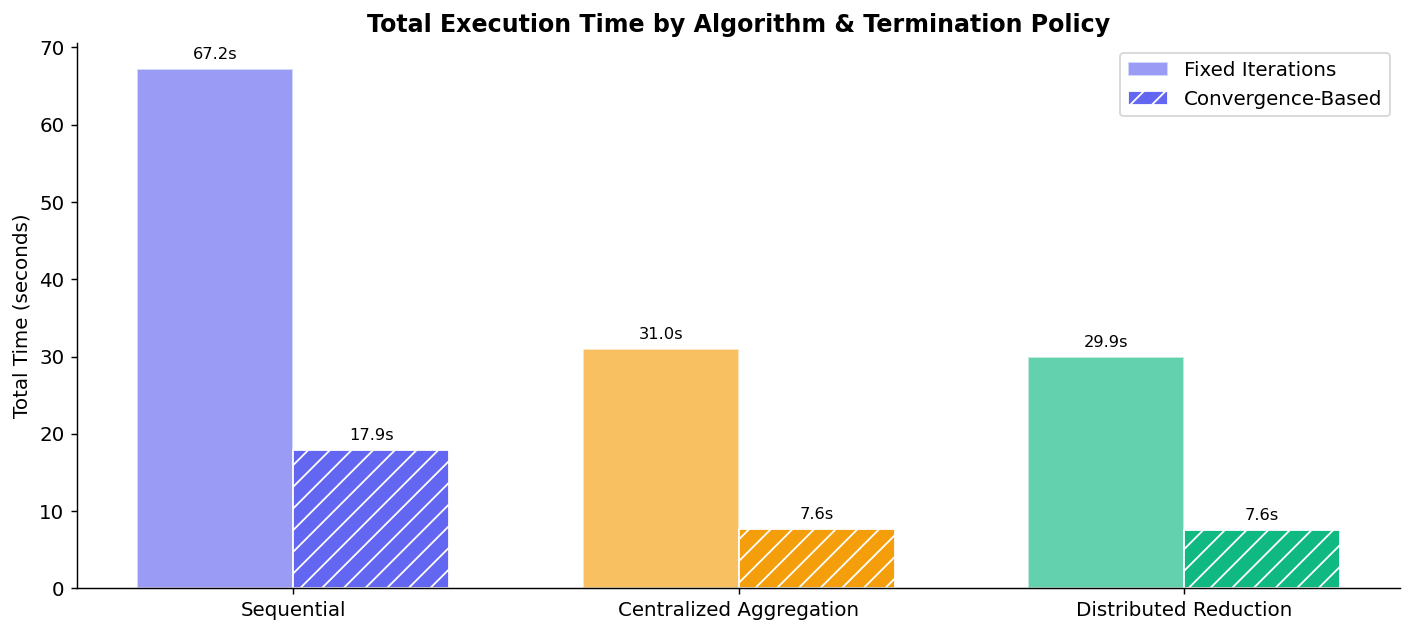

In [76]:
COLORS = {
    'Sequential'            : '#6366F1',
    'Centralized Aggregation': '#F59E0B',
    'Distributed Reduction' : '#10B981',
}

algos = ['Sequential', 'Centralized Aggregation', 'Distributed Reduction']
fixed_times = [seq_fixed['total_time'], ca_fixed['total_time'], dr_fixed['total_time']]
conv_times  = [seq_conv['total_time'],  ca_conv['total_time'],  dr_conv['total_time']]

x     = np.arange(len(algos))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_f = ax.bar(x - width/2, fixed_times, width, label='Fixed Iterations',
                color=[COLORS[a] for a in algos], alpha=0.65, edgecolor='white')
bars_c = ax.bar(x + width/2, conv_times,  width, label='Convergence-Based',
                color=[COLORS[a] for a in algos], alpha=1.0,  edgecolor='white',
                hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(algos)
ax.set_ylabel('Total Time (seconds)')
ax.set_title('Total Execution Time by Algorithm & Termination Policy', fontweight='bold')
ax.legend()

for bar in list(bars_f) + list(bars_c):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}s',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{img_out_dir}/total_time_comparison.png', bbox_inches='tight')
plt.show()

### 7.2 Speedup vs Sequential Baseline

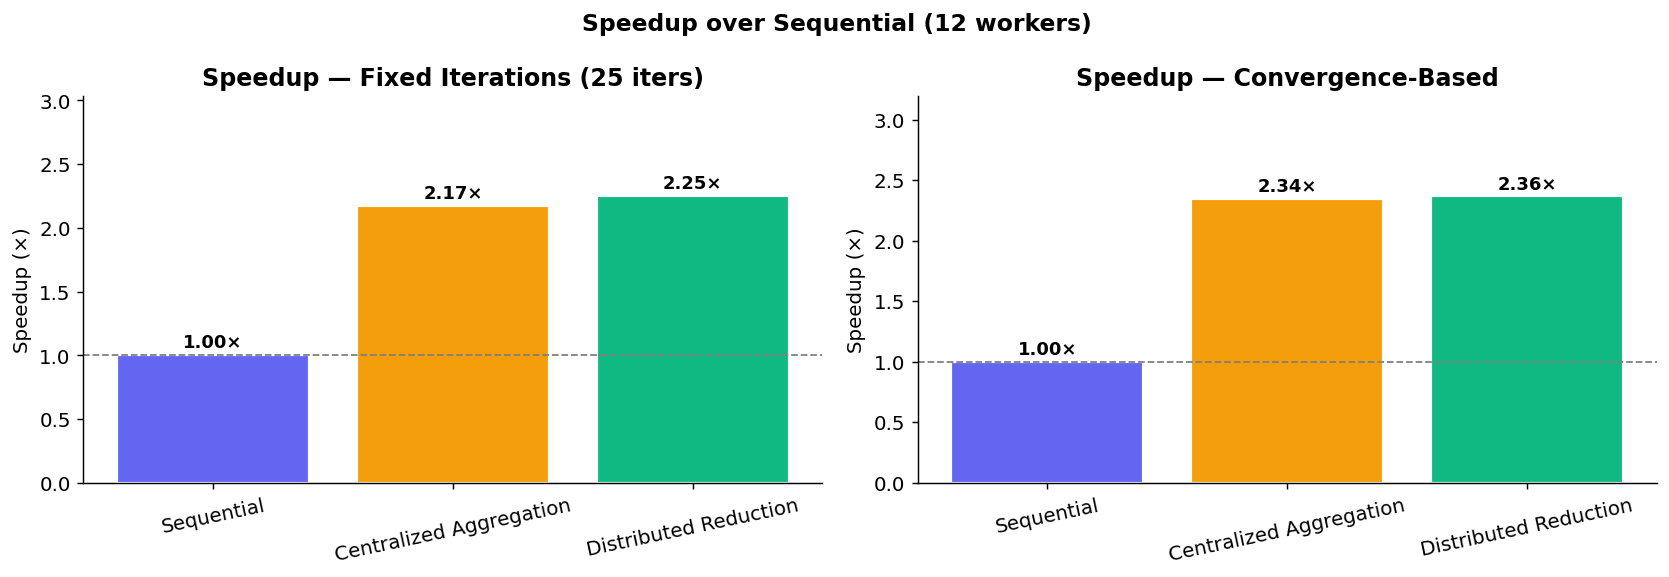

In [77]:
speedups_fixed = [t / f for t, f in zip([seq_fixed_time]*3, fixed_times)]
speedups_conv  = [t / c for t, c in zip([seq_conv_time]*3,  conv_times)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, speedups, title, n_iters in [
    (axes[0], speedups_fixed, f'Fixed Iterations ({FIXED_ITERS} iters)', FIXED_ITERS),
    (axes[1], speedups_conv,  'Convergence-Based', None),
]:
    bars = ax.bar(algos, speedups,
                  color=[COLORS[a] for a in algos],
                  edgecolor='white', linewidth=1.2)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Sequential baseline')
    ax.set_title(f'Speedup — {title}', fontweight='bold')
    ax.set_ylabel('Speedup (×)')
    ax.set_ylim(0, max(speedups) * 1.35)
    ax.tick_params(axis='x', rotation=12)

    for bar, s in zip(bars, speedups):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{s:.2f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle(f'Speedup over Sequential ({NUM_WORKERS} workers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{img_out_dir}/speedup.png', bbox_inches='tight')
plt.show()

### 7.3 Per-Iteration Time Breakdown

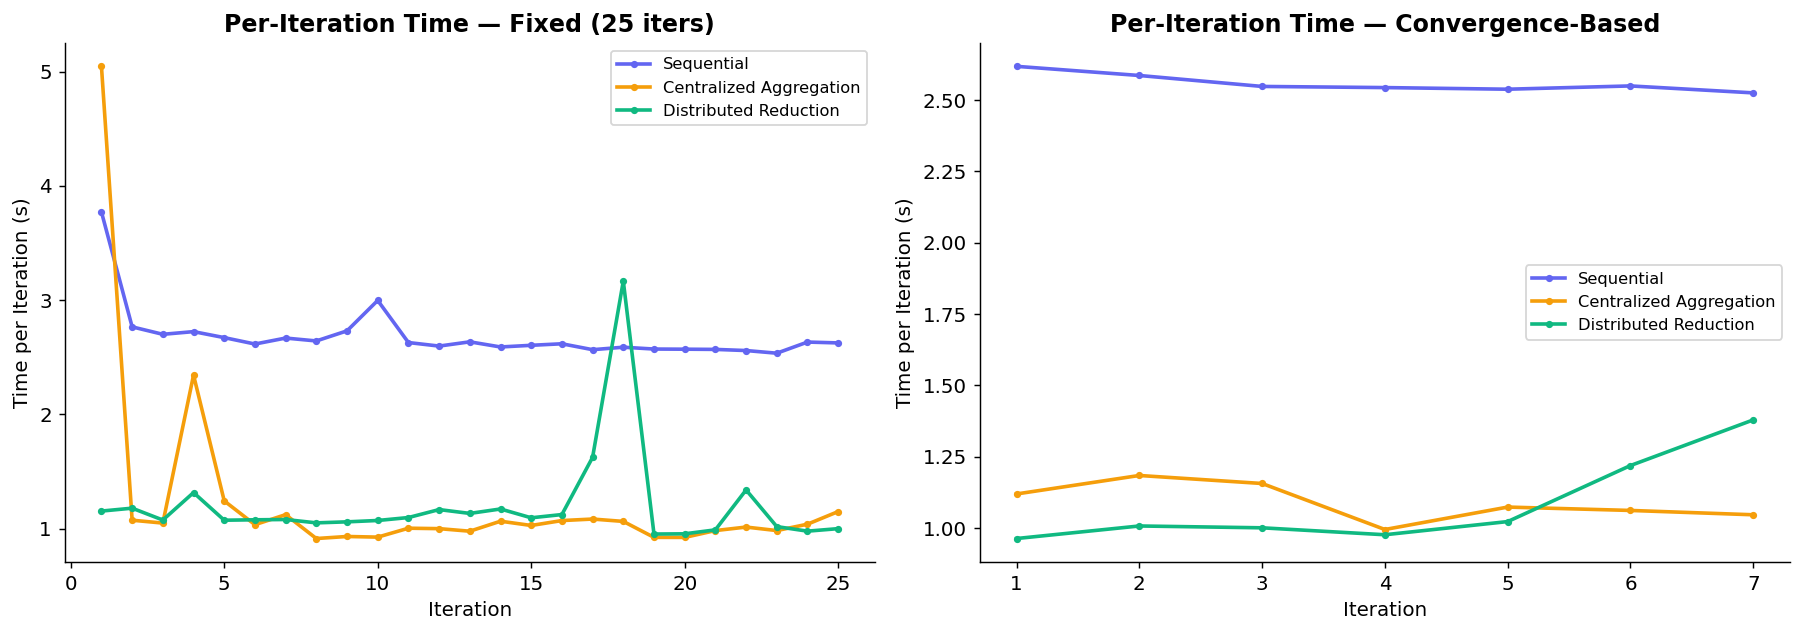

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mode_label, datasets in [
    (axes[0], f'Fixed ({FIXED_ITERS} iters)', [
        ('Sequential',             seq_fixed['iter_times'], '#6366F1'),
        ('Centralized Aggregation',ca_fixed['iter_times'],  '#F59E0B'),
        ('Distributed Reduction',  dr_fixed['iter_times'],  '#10B981'),
    ]),
    (axes[1], 'Convergence-Based', [
        ('Sequential',             seq_conv['iter_times'], '#6366F1'),
        ('Centralized Aggregation',ca_conv['iter_times'],  '#F59E0B'),
        ('Distributed Reduction',  dr_conv['iter_times'],  '#10B981'),
    ]),
]:
    for label, times, color in datasets:
        ax.plot(range(1, len(times)+1), times,
                label=label, color=color, linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Time per Iteration (s)')
    ax.set_title(f'Per-Iteration Time — {mode_label}', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{img_out_dir}/per_iter_time.png', bbox_inches='tight')
plt.show()

### 7.4 Convergence Curves (Max Diff per Iteration)

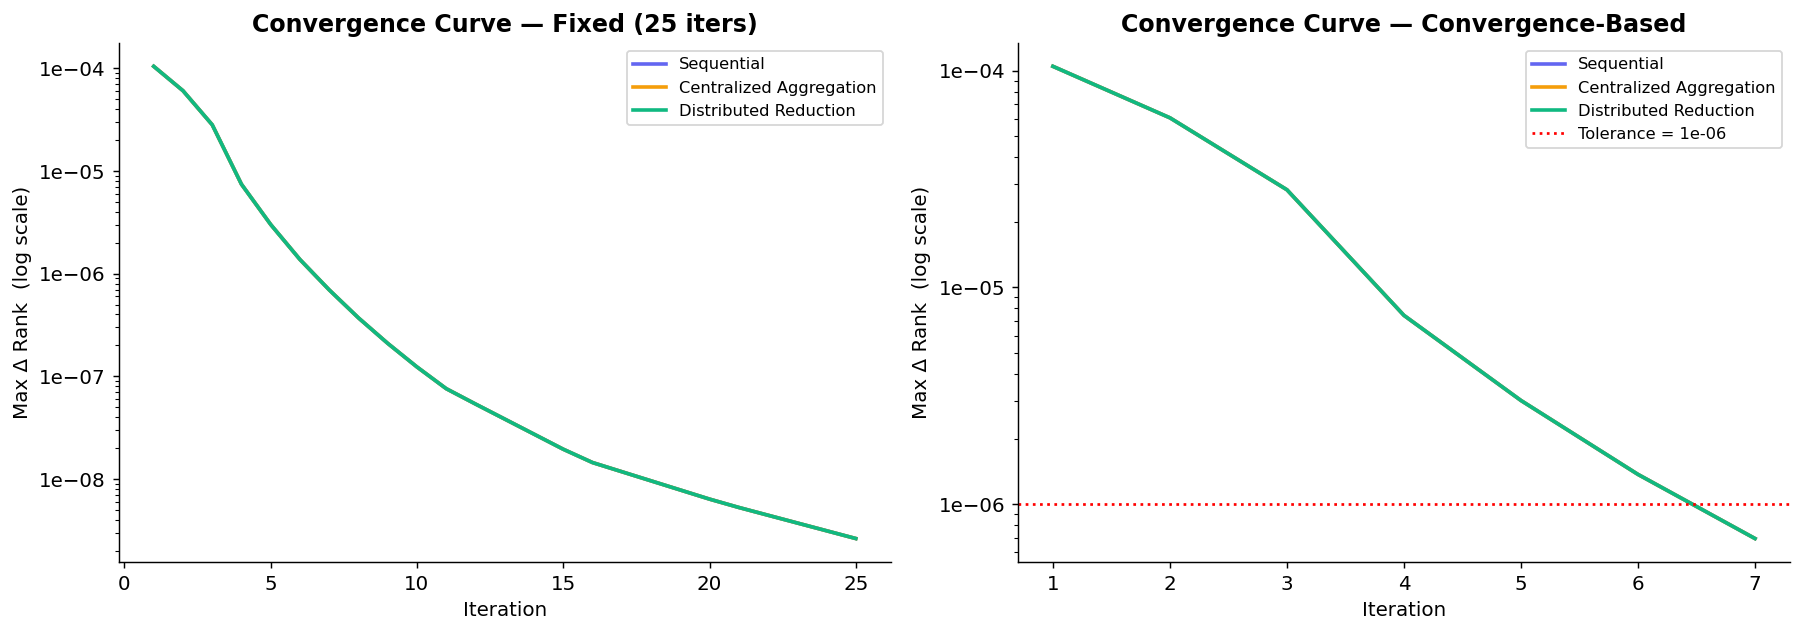

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mode_label, datasets in [
    (axes[0], f'Fixed ({FIXED_ITERS} iters)', [
        ('Sequential',             seq_fixed['iter_diffs'], '#6366F1'),
        ('Centralized Aggregation',ca_fixed['iter_diffs'],  '#F59E0B'),
        ('Distributed Reduction',  dr_fixed['iter_diffs'],  '#10B981'),
    ]),
    (axes[1], 'Convergence-Based', [
        ('Sequential',             seq_conv['iter_diffs'], '#6366F1'),
        ('Centralized Aggregation',ca_conv['iter_diffs'],  '#F59E0B'),
        ('Distributed Reduction',  dr_conv['iter_diffs'],  '#10B981'),
    ]),
]:
    for label, diffs, color in datasets:
        ax.semilogy(range(1, len(diffs)+1), diffs,
                    label=label, color=color, linewidth=2)

    # Draw convergence threshold line only for convergence panel
    if 'Convergence' in mode_label:
        ax.axhline(TOLERANCE, color='red', linestyle=':', linewidth=1.5,
                   label=f'Tolerance = {TOLERANCE:.0e}')

    ax.set_xlabel('Iteration')
    ax.set_ylabel('Max Δ Rank  (log scale)')
    ax.set_title(f'Convergence Curve — {mode_label}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.LogFormatter())

plt.tight_layout()
plt.savefig(f'{img_out_dir}/convergence_curves.png', bbox_inches='tight')
plt.show()

### 7.5 Communication Overhead Analysis (Parallel Modes)

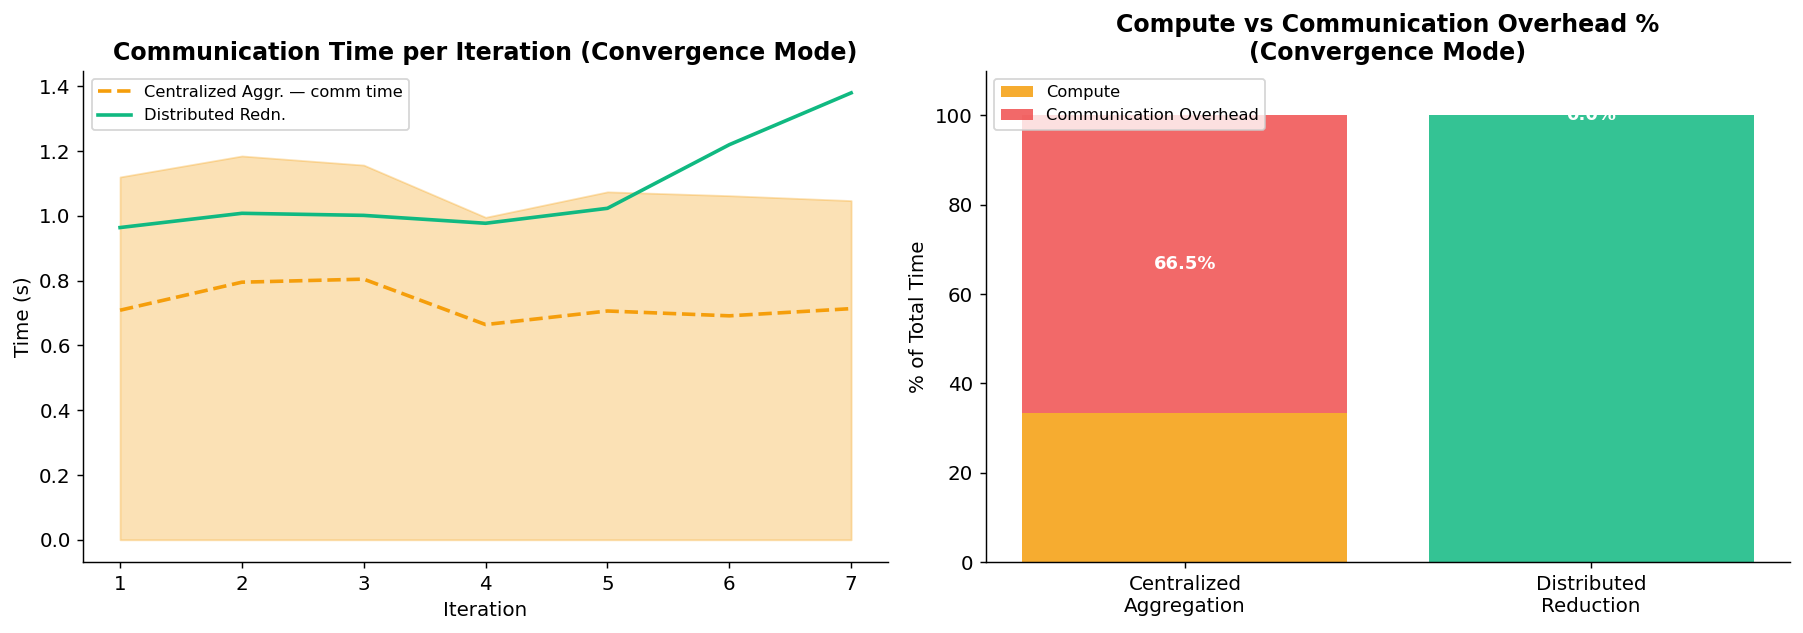

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: comm time vs compute time per iteration ─────────────────────
ax = axes[0]
for res, label, color in [
    (ca_conv,  'Centralized Aggr.', '#F59E0B'),
    (dr_conv,  'Distributed Redn.', '#10B981'),
]:
    iters     = range(1, len(res['iter_times']) + 1)
    comp_only = np.array(res['iter_times'])

    if 'comm_times' in res:
        comm = np.array(res['comm_times'])
        ax.fill_between(iters, 0, comp_only, alpha=0.3, color=color)
        ax.plot(iters, comm, label=f'{label} — comm time', color=color,
                linewidth=2, linestyle='--')
    else:
        ax.plot(iters, comp_only, label=label, color=color, linewidth=2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Time (s)')
ax.set_title('Communication Time per Iteration (Convergence Mode)',
             fontweight='bold')
ax.legend(fontsize=9)

# ── Right: Comm overhead % pie-style stacked bar ──────────────────────
ax = axes[1]
algo_labels  = ['Centralized\nAggregation', 'Distributed\nReduction']

def overhead_pct(res):
    if 'comm_times' in res:
        return 100 * np.sum(res['comm_times']) / res['total_time']
    return 0.0

comm_pcts   = [overhead_pct(ca_conv), overhead_pct(dr_conv)]
compute_pcts= [100 - p for p in comm_pcts]

x  = np.arange(len(algo_labels))
b1 = ax.bar(x, compute_pcts, label='Compute',       color=['#F59E0B', '#10B981'], alpha=0.85)
b2 = ax.bar(x, comm_pcts,   bottom=compute_pcts,
            label='Communication Overhead', color='#EF4444', alpha=0.80)

ax.set_xticks(x)
ax.set_xticklabels(algo_labels)
ax.set_ylim(0, 110)
ax.set_ylabel('% of Total Time')
ax.set_title('Compute vs Communication Overhead %\n(Convergence Mode)', fontweight='bold')
ax.legend(fontsize=9)

for bar, pct in zip(b2, comm_pcts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(f'{img_out_dir}/comm_overhead.png', bbox_inches='tight')
plt.show()

### 7.6 Fixed vs Convergence — Iteration Count & Time Trade-off

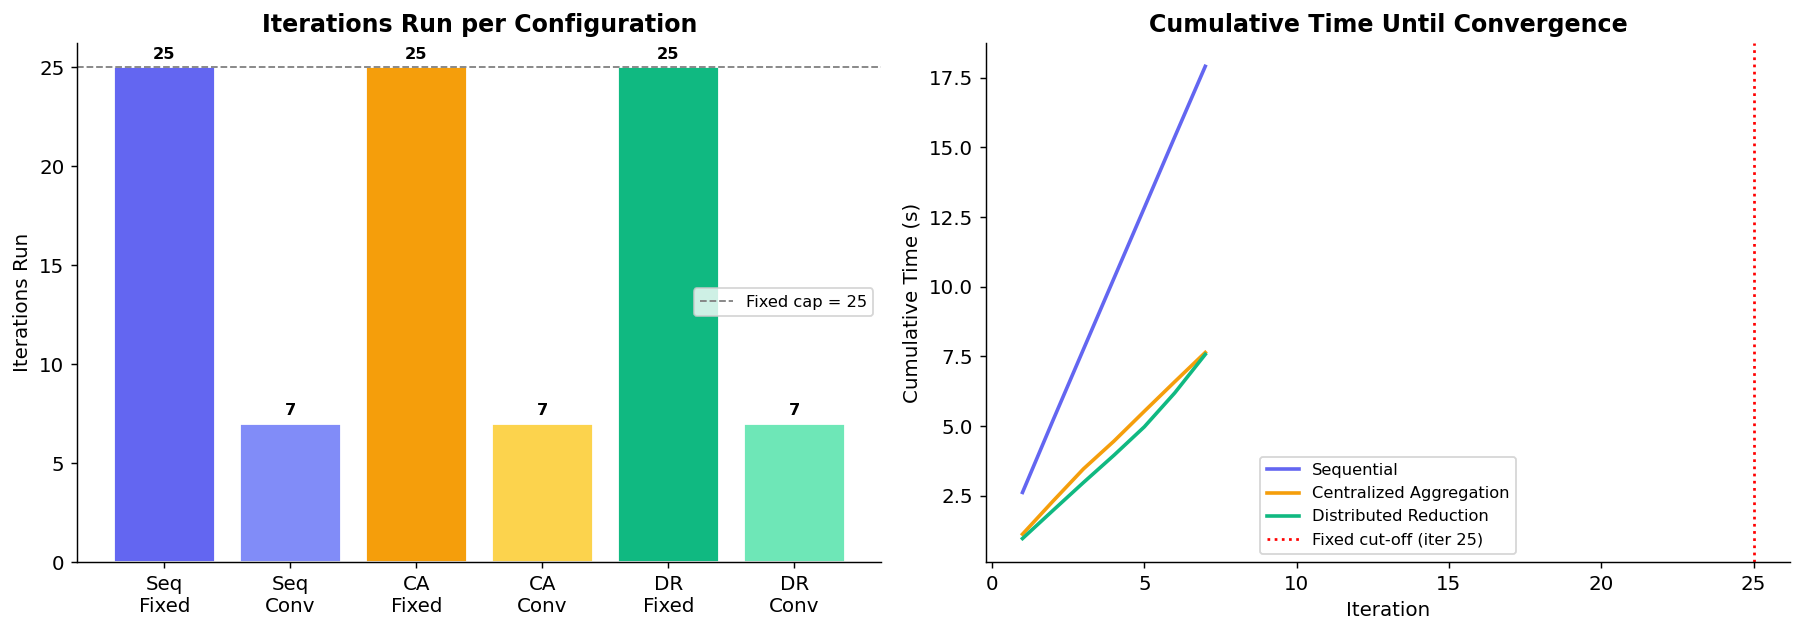

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: iteration count comparison ──────────────────────────────────
ax = axes[0]
all_labels = [
    'Seq\nFixed', 'Seq\nConv',
    'CA\nFixed',  'CA\nConv',
    'DR\nFixed',  'DR\nConv',
]
all_results = [seq_fixed, seq_conv, ca_fixed, ca_conv, dr_fixed, dr_conv]
iter_counts = [len(r['iter_times']) for r in all_results]
colors_bar  = ['#6366F1','#818CF8', '#F59E0B','#FCD34D', '#10B981','#6EE7B7']

bars = ax.bar(all_labels, iter_counts, color=colors_bar, edgecolor='white')
ax.axhline(FIXED_ITERS, color='gray', linestyle='--', linewidth=1,
           label=f'Fixed cap = {FIXED_ITERS}')
ax.set_ylabel('Iterations Run')
ax.set_title('Iterations Run per Configuration', fontweight='bold')
ax.legend(fontsize=9)
for bar, cnt in zip(bars, iter_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Right: cumulative time comparison (convergence overhead) ───────────
ax = axes[1]
for res, label, color, ls in [
    (seq_conv, 'Sequential',             '#6366F1', '-'),
    (ca_conv,  'Centralized Aggregation','#F59E0B', '-'),
    (dr_conv,  'Distributed Reduction',  '#10B981', '-'),
]:
    cum_times = np.cumsum(res['iter_times'])
    ax.plot(range(1, len(cum_times)+1), cum_times,
            label=label, color=color, linewidth=2, linestyle=ls)

# Mark the fixed-iter cut-off
ax.axvline(FIXED_ITERS, color='red', linestyle=':', linewidth=1.5,
           label=f'Fixed cut-off (iter {FIXED_ITERS})')

ax.set_xlabel('Iteration')
ax.set_ylabel('Cumulative Time (s)')
ax.set_title('Cumulative Time Until Convergence', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{img_out_dir}/fixed_vs_convergence.png', bbox_inches='tight')
plt.show()

### 7.7 PageRank Score Distribution & Top Pages

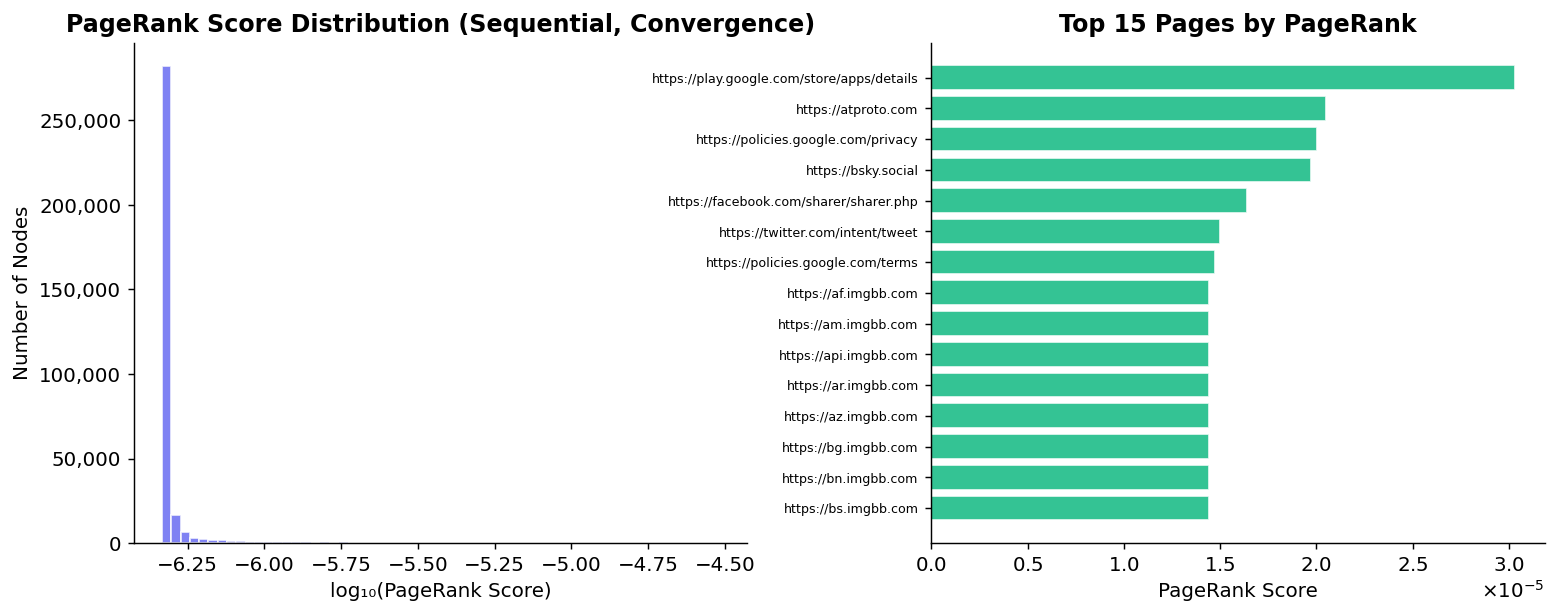

In [82]:
fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 2, figure=fig, wspace=0.3)

# ── Left: PageRank score distribution (log scale) ─────────────────────
ax1 = fig.add_subplot(gs[0])
ranks_arr = np.array(list(seq_conv['ranks'].values()))
ax1.hist(np.log10(ranks_arr + 1e-20), bins=60,
         color='#6366F1', alpha=0.82, edgecolor='white')
ax1.set_xlabel('log₁₀(PageRank Score)')
ax1.set_ylabel('Number of Nodes')
ax1.set_title('PageRank Score Distribution (Sequential, Convergence)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── Right: Top 15 pages horizontal bar ────────────────────────────────
ax2 = fig.add_subplot(gs[1])
top15 = sorted(seq_conv['ranks'].items(), key=lambda x: x[1], reverse=True)[:15]
urls  = [u[:45] + '…' if len(u) > 45 else u for u, _ in top15]
scores= [s for _, s in top15]

bars = ax2.barh(range(len(top15)), scores[::-1],   # flip so top rank is at top
                color='#10B981', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(urls[::-1], fontsize=7)
ax2.set_xlabel('PageRank Score')
ax2.set_title('Top 15 Pages by PageRank', fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))

plt.savefig(f'{img_out_dir}/pagerank_scores.png', bbox_inches='tight')
plt.show()

### 7.8 Algorithm Comparison Dashboard (Combined)

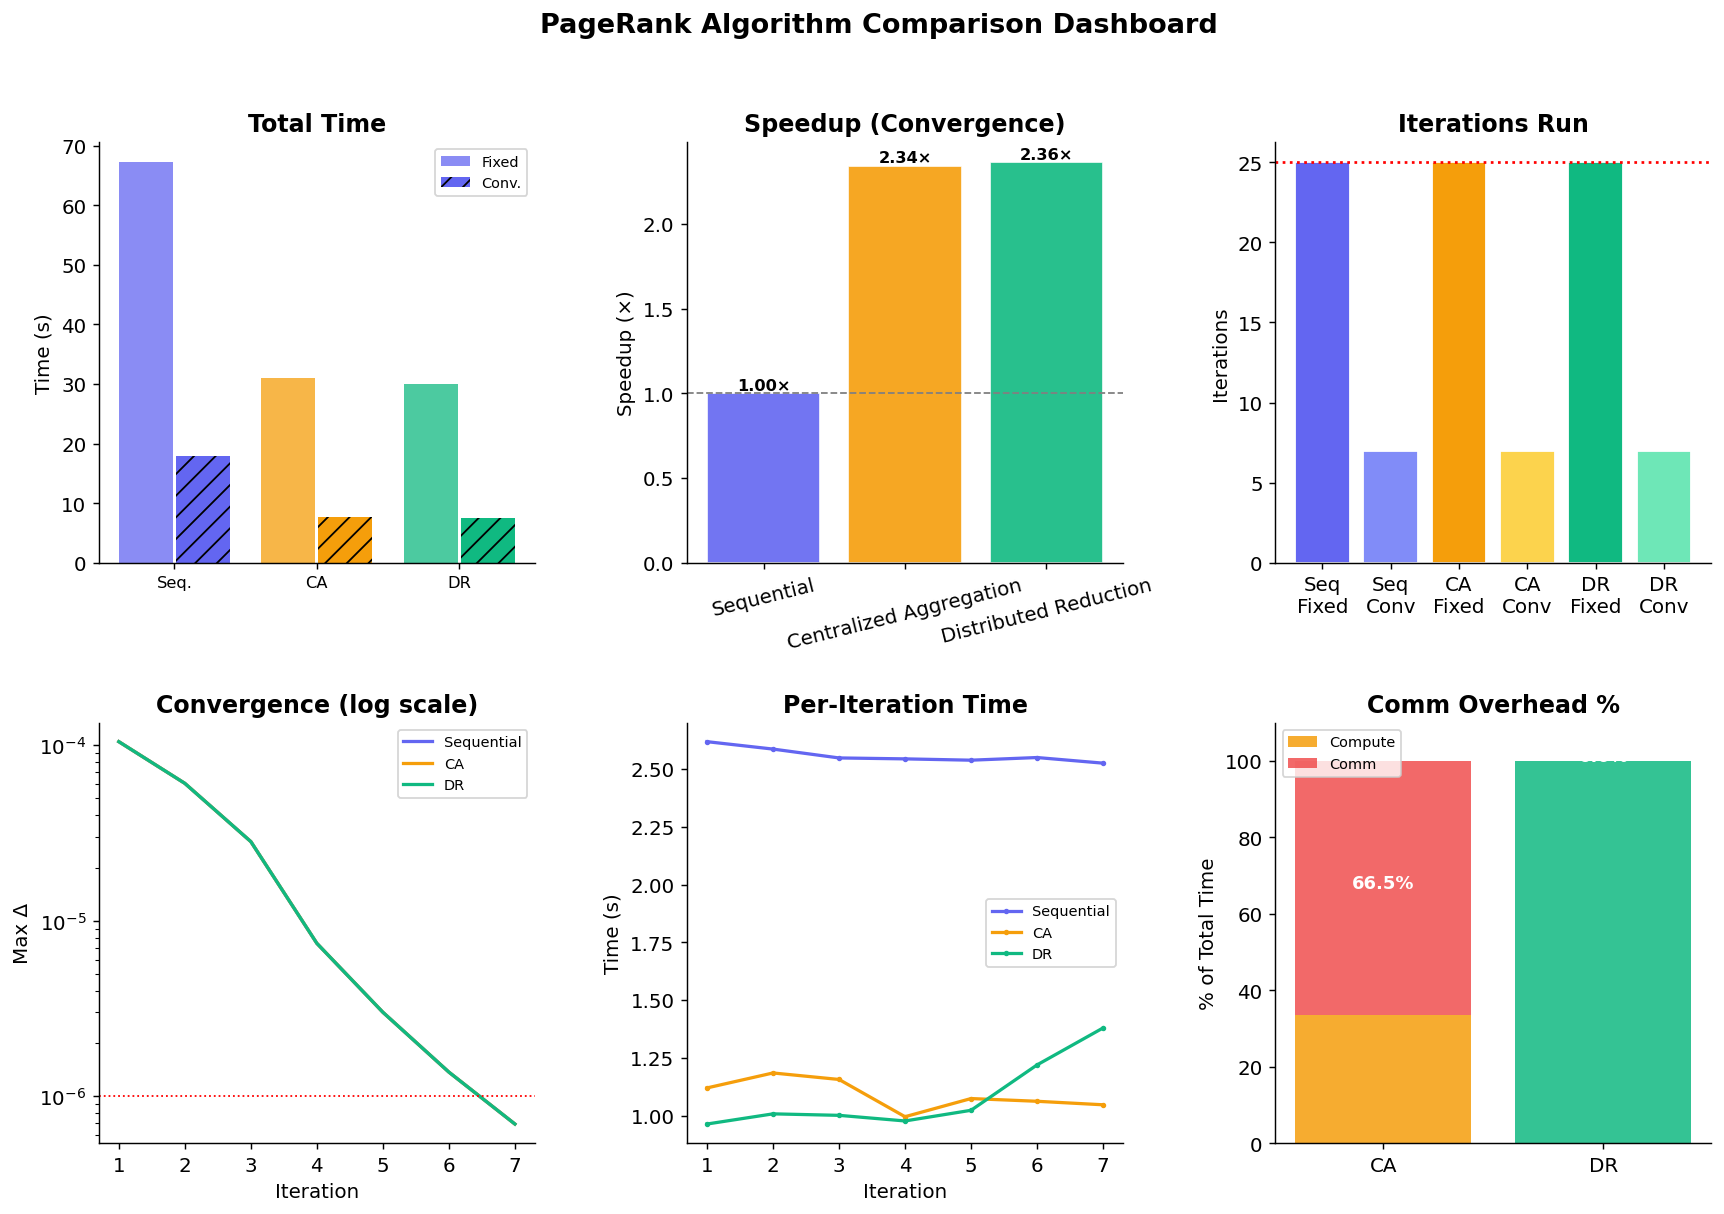

In [83]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('PageRank Algorithm Comparison Dashboard', fontsize=15, fontweight='bold', y=0.98)
gs  = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# ── (0,0) Total time grouped bar ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
x  = np.arange(3)
ax.bar(x - 0.2, fixed_times, 0.38, label='Fixed', alpha=0.75,
       color=[COLORS[a] for a in algos])
ax.bar(x + 0.2, conv_times,  0.38, label='Conv.',  alpha=1.0,
       color=[COLORS[a] for a in algos], hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(['Seq.', 'CA', 'DR'], fontsize=9)
ax.set_ylabel('Time (s)');  ax.set_title('Total Time', fontweight='bold')
ax.legend(fontsize=8)

# ── (0,1) Speedup ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.bar(algos, speedups_conv, color=[COLORS[a] for a in algos], alpha=0.9, edgecolor='white')
ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Speedup (×)');  ax.set_title('Speedup (Convergence)', fontweight='bold')
ax.tick_params(axis='x', rotation=14)
for i, s in enumerate(speedups_conv):
    ax.text(i, s + 0.02, f'{s:.2f}×', ha='center', fontsize=9, fontweight='bold')

# ── (0,2) Iterations run ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
ax.bar(all_labels, iter_counts, color=colors_bar, edgecolor='white')
ax.axhline(FIXED_ITERS, color='red', linestyle=':', linewidth=1.5)
ax.set_ylabel('Iterations');  ax.set_title('Iterations Run', fontweight='bold')

# ── (1,0) Convergence curves ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
for res, label, color in [
    (seq_conv, 'Sequential',  '#6366F1'),
    (ca_conv,  'CA',          '#F59E0B'),
    (dr_conv,  'DR',          '#10B981'),
]:
    ax.semilogy(range(1, len(res['iter_diffs'])+1), res['iter_diffs'],
                label=label, color=color, linewidth=1.8)
ax.axhline(TOLERANCE, color='red', linestyle=':', linewidth=1)
ax.set_xlabel('Iteration');  ax.set_ylabel('Max Δ')
ax.set_title('Convergence (log scale)', fontweight='bold')
ax.legend(fontsize=8)

# ── (1,1) Per-iteration time ──────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
for res, label, color in [
    (seq_conv, 'Sequential',  '#6366F1'),
    (ca_conv,  'CA',          '#F59E0B'),
    (dr_conv,  'DR',          '#10B981'),
]:
    ax.plot(range(1, len(res['iter_times'])+1), res['iter_times'],
            label=label, color=color, linewidth=1.8, marker='o', markersize=2)
ax.set_xlabel('Iteration');  ax.set_ylabel('Time (s)')
ax.set_title('Per-Iteration Time', fontweight='bold')
ax.legend(fontsize=8)

# ── (1,2) Comm overhead stacked bar ───────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.bar(['CA', 'DR'],
       [100 - comm_pcts[0], 100 - comm_pcts[1]],
       color=['#F59E0B', '#10B981'], alpha=0.85, label='Compute')
ax.bar(['CA', 'DR'], comm_pcts,
       bottom=[100 - comm_pcts[0], 100 - comm_pcts[1]],
       color='#EF4444', alpha=0.8, label='Comm')
ax.set_ylim(0, 110);  ax.set_ylabel('% of Total Time')
ax.set_title('Comm Overhead %', fontweight='bold')
ax.legend(fontsize=8)
for i, pct in enumerate(comm_pcts):
    ax.text(i, 100 - comm_pcts[i] + comm_pcts[i]/2,
            f'{pct:.1f}%', ha='center', color='white', fontweight='bold', fontsize=10)

plt.savefig(f'{img_out_dir}/dashboard.png', bbox_inches='tight', dpi=140)
plt.show()

## 8 · Numerical Correctness Check

All three algorithms should produce **identical ranks** (within floating-point tolerance).

In [84]:
# Compare convergence-mode ranks pairwise
nodes_sorted  = sorted(seq_conv['ranks'].keys())
seq_arr       = np.array([seq_conv['ranks'][n] for n in nodes_sorted])
ca_arr        = np.array([ca_conv ['ranks'][n] for n in nodes_sorted])
dr_arr        = np.array([dr_conv ['ranks'][n] for n in nodes_sorted])

print('─── Numerical Correctness (Convergence Mode) ─────────────────────')
print(f'Seq  vs CA   — max abs diff: {np.max(np.abs(seq_arr - ca_arr)):.2e}')
print(f'Seq  vs DR   — max abs diff: {np.max(np.abs(seq_arr - dr_arr)):.2e}')
print(f'CA   vs DR   — max abs diff: {np.max(np.abs(ca_arr  - dr_arr)):.2e}')

tol_check = 1e-5   # slightly relaxed for parallel floating-point order
ok_ca = np.allclose(seq_arr, ca_arr, atol=tol_check)
ok_dr = np.allclose(seq_arr, dr_arr, atol=tol_check)
print(f'\nSeq ≈ CA (atol={tol_check:.0e}): {"✓ PASS" if ok_ca else "✗ FAIL"}')
print(f'Seq ≈ DR (atol={tol_check:.0e}): {"✓ PASS" if ok_dr else "✗ FAIL"}')

# Top-5 rank agreement
top5_seq = sorted(seq_conv['ranks'].items(), key=lambda x: x[1], reverse=True)[:5]
top5_ca  = sorted(ca_conv ['ranks'].items(), key=lambda x: x[1], reverse=True)[:5]
top5_dr  = sorted(dr_conv ['ranks'].items(), key=lambda x: x[1], reverse=True)[:5]

print('\n── Top-5 URL Agreement ──')
for rank, (s, c, d) in enumerate(
        zip(top5_seq, top5_ca, top5_dr), start=1):
    match = '✓' if s[0] == c[0] == d[0] else '✗'
    print(f'  {rank}. {match}  Seq: {s[0][:50]}   CA: {c[0][:50]}   DR: {d[0][:50]}')

─── Numerical Correctness (Convergence Mode) ─────────────────────
Seq  vs CA   — max abs diff: 0.00e+00
Seq  vs DR   — max abs diff: 0.00e+00
CA   vs DR   — max abs diff: 0.00e+00

Seq ≈ CA (atol=1e-05): ✓ PASS
Seq ≈ DR (atol=1e-05): ✓ PASS

── Top-5 URL Agreement ──
  1. ✓  Seq: https://play.google.com/store/apps/details   CA: https://play.google.com/store/apps/details   DR: https://play.google.com/store/apps/details
  2. ✓  Seq: https://atproto.com   CA: https://atproto.com   DR: https://atproto.com
  3. ✓  Seq: https://policies.google.com/privacy   CA: https://policies.google.com/privacy   DR: https://policies.google.com/privacy
  4. ✓  Seq: https://bsky.social   CA: https://bsky.social   DR: https://bsky.social
  5. ✓  Seq: https://facebook.com/sharer/sharer.php   CA: https://facebook.com/sharer/sharer.php   DR: https://facebook.com/sharer/sharer.php


## 9 · Detailed Analysis & Interpretation

### 9.1 Summary Table (Pretty Print)

In [85]:
df_disp = df_summary.reset_index().copy()

styled = (
    df_disp.style
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1E293B'),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '8px'),
        ]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
        {'selector': 'tr:nth-child(even)', 'props':
            [('background-color', '#F8FAFC')]},
    ])
    .background_gradient(subset=['Total Time (s)'],  cmap='RdYlGn_r', vmin=0)
    .background_gradient(subset=['Speedup vs Seq'],  cmap='RdYlGn',   vmin=0)
    .background_gradient(subset=['Comm Overhead %'], cmap='YlOrRd',   vmin=0)
    .format({'Speedup vs Seq': '{:.3f}×', 'Total Time (s)': '{:.3f}'})
    .set_caption(
        f'PageRank Benchmark · {N:,} nodes · d={DAMPING} · '
        f'tol={TOLERANCE:.0e} · {NUM_WORKERS} workers'
    )
)
styled

Algorithm,Mode,Iterations Run,Converged At,Total Time (s),Avg Iter Time (s),Speedup vs Seq,Comm Overhead %,Final Max Diff
Sequential,Fixed,25,25,67.244,2.686900,1.000×,0.000000,2.63e-09
Sequential,Convergence,7,7,17.908,2.558200,1.000×,0.000000,6.94e-07
Centralized Aggregation,Fixed,25,25,30.975,1.238900,2.171×,68.800000,2.63e-09
Centralized Aggregation,Convergence,7,7,7.640,1.091300,2.344×,66.500000,6.94e-07
Distributed Reduction,Fixed,25,25,29.929,1.197100,2.247×,0.000000,2.63e-09
Distributed Reduction,Convergence,7,7,7.572,1.081600,2.365×,0.000000,6.94e-07


### 9.2 Efficiency & Amdahl's Law Estimate

Amdahl's Law Analysis
  Workers used   : 12

  Centralized Aggregation (Conv.)
    Actual speedup      : 2.344x
    Parallel efficiency : 19.5%
    Estimated p (Amdahl): 0.626
    Theoretical max     : 2.7x

  Distributed Reduction  (Conv.)
    Actual speedup      : 2.365x
    Parallel efficiency : 19.7%
    Estimated p (Amdahl): 0.630
    Theoretical max     : 2.7x



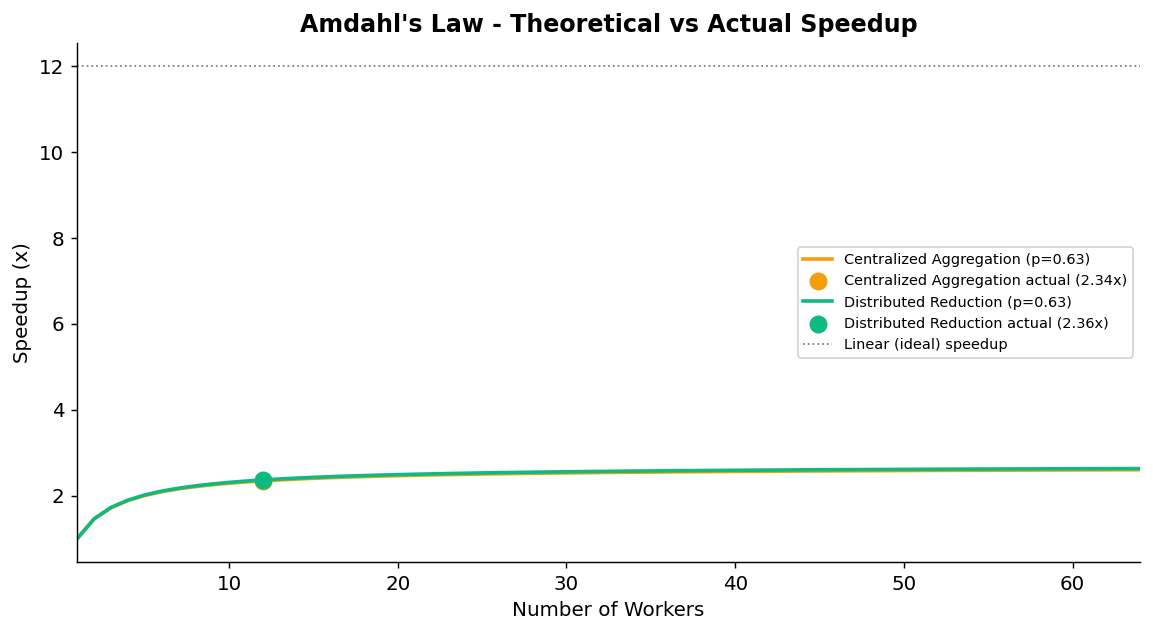

In [86]:
# Estimate parallel fraction from actual speedup (Amdahl)
# Speedup = 1 / ((1-p) + p/N)  =>  solve for p

def amdahl_parallel_fraction(speedup, n_workers):
    """Invert Amdahl's law to estimate the parallel fraction p."""
    if speedup <= 1:
        return 0.0
    # S = 1/((1-p) + p/n) => p = (1/S - 1) / (1/n - 1)
    inv_s = 1.0 / speedup
    inv_n = 1.0 / n_workers
    if abs(inv_n - 1) < 1e-12:
        return float('nan')
    p = (inv_s - 1.0) / (inv_n - 1.0)
    return max(0.0, min(1.0, p))


def theoretical_speedup(p, n):
    return 1.0 / ((1 - p) + p / n)


print('Amdahl\'s Law Analysis')
print(f'  Workers used   : {NUM_WORKERS}')
print()

for label, res, baseline in [
    ('Centralized Aggregation (Conv.)', ca_conv, seq_conv_time),
    ('Distributed Reduction  (Conv.)', dr_conv, seq_conv_time),
]:
    actual_su = baseline / res['total_time']
    p = amdahl_parallel_fraction(actual_su, NUM_WORKERS)
    print(f'  {label}')
    print(f'    Actual speedup      : {actual_su:.3f}x')
    print(f'    Parallel efficiency : {actual_su / NUM_WORKERS * 100:.1f}%')
    print(f'    Estimated p (Amdahl): {p:.3f}')
    print(f'    Theoretical max     : {1/(1-p) if p < 1 else float("inf"):.1f}x')
    print()

# Plot theoretical Amdahl curves
worker_range = np.arange(1, 65)
fig, ax = plt.subplots(figsize=(9, 5))

for label, res, baseline, color in [
    ('Centralized Aggregation', ca_conv, seq_conv_time, '#F59E0B'),
    ('Distributed Reduction', dr_conv, seq_conv_time, '#10B981'),
]:
    actual_su = baseline / res['total_time']
    p = amdahl_parallel_fraction(actual_su, NUM_WORKERS)
    curve = [theoretical_speedup(p, n) for n in worker_range]
    ax.plot(worker_range, curve, label=f'{label} (p={p:.2f})', color=color, linewidth=2)
    ax.scatter(
        [NUM_WORKERS],
        [actual_su],
        color=color,
        s=80,
        zorder=5,
        label=f'{label} actual ({actual_su:.2f}x)'
    )

ax.axhline(NUM_WORKERS, color='gray', linestyle=':', linewidth=1, label='Linear (ideal) speedup')
ax.set_xlabel('Number of Workers')
ax.set_ylabel('Speedup (x)')
ax.set_title("Amdahl's Law - Theoretical vs Actual Speedup", fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(1, 64)
plt.tight_layout()
plt.savefig(f'{img_out_dir}/amdahl.png', bbox_inches='tight')
plt.show()

### 9.3 Fixed vs Convergence — When does stopping early matter?

In [87]:
# How similar are the fixed-iter ranks to converged ranks?
print('── Rank Quality of Fixed-Iteration Stopping ──────────────────────')
print(f'Fixed iters ran : {FIXED_ITERS}')
print()

for label, fixed_res, conv_res in [
    ('Sequential',             seq_fixed, seq_conv),
    ('Centralized Aggregation', ca_fixed, ca_conv),
    ('Distributed Reduction',   dr_fixed, dr_conv),
]:
    nodes   = sorted(fixed_res['ranks'].keys())
    f_arr   = np.array([fixed_res['ranks'][n] for n in nodes])
    c_arr   = np.array([conv_res ['ranks'][n] for n in nodes])
    max_d   = np.max(np.abs(f_arr - c_arr))
    mean_d  = np.mean(np.abs(f_arr - c_arr))
    
    # Rank-order correlation (top 100)
    top100_fixed = sorted(fixed_res['ranks'].items(), key=lambda x: x[1], reverse=True)[:100]
    top100_conv  = sorted(conv_res['ranks'].items(),  key=lambda x: x[1], reverse=True)[:100]
    urls_fixed   = [u for u, _ in top100_fixed]
    urls_conv    = [u for u, _ in top100_conv]
    overlap_pct  = 100 * len(set(urls_fixed) & set(urls_conv)) / 100

    print(f'  {label}')
    print(f'    Max  |fixed - converged|  : {max_d:.4e}')
    print(f'    Mean |fixed - converged|  : {mean_d:.4e}')
    print(f'    Top-100 URL overlap       : {overlap_pct:.0f}%')
    print(f'    Fixed diff at iter {FIXED_ITERS}     : {fixed_res["iter_diffs"][-1]:.4e}')
    print(f'    Converged at iteration    : {conv_res["converged_at"]}')
    print()

── Rank Quality of Fixed-Iteration Stopping ──────────────────────
Fixed iters ran : 25

  Sequential
    Max  |fixed - converged|  : 9.2382e-07
    Mean |fixed - converged|  : 1.2733e-09
    Top-100 URL overlap       : 99%
    Fixed diff at iter 25     : 2.6257e-09
    Converged at iteration    : 7

  Centralized Aggregation
    Max  |fixed - converged|  : 9.2382e-07
    Mean |fixed - converged|  : 1.2733e-09
    Top-100 URL overlap       : 99%
    Fixed diff at iter 25     : 2.6257e-09
    Converged at iteration    : 7

  Distributed Reduction
    Max  |fixed - converged|  : 9.2382e-07
    Mean |fixed - converged|  : 1.2733e-09
    Top-100 URL overlap       : 99%
    Fixed diff at iter 25     : 2.6257e-09
    Converged at iteration    : 7



## 10 · Conclusions

### Key Findings

In [88]:
# Auto-generate text conclusions from actual measured numbers
ca_su_conv = seq_conv_time / ca_conv['total_time']
dr_su_conv = seq_conv_time / dr_conv['total_time']
ca_su_fixed= seq_fixed_time/ ca_fixed['total_time']
dr_su_fixed= seq_fixed_time/ dr_fixed['total_time']

ca_comm_pct = overhead_pct(ca_conv)
dr_comm_pct = overhead_pct(dr_conv)

conv_iters  = seq_conv['converged_at']
early_stop  = conv_iters <= FIXED_ITERS

print('=' * 65)
print('           PAGERANK BENCHMARK — KEY CONCLUSIONS')
print('=' * 65)
print(f"""
1. PARALLELISM BENEFIT
   • Sequential is the slowest for both policies.
   • Centralized Aggregation achieves {ca_su_conv:.2f}× speedup (convergence)
     and {ca_su_fixed:.2f}× speedup (fixed {FIXED_ITERS} iters).
   • Distributed Reduction achieves  {dr_su_conv:.2f}× speedup (convergence)
     and {dr_su_fixed:.2f}× speedup (fixed {FIXED_ITERS} iters).

2. AGGREGATION STRATEGY
   • Centralized aggregation is simpler but forces ALL partial results
     through the driver: {ca_comm_pct:.1f}% of its total time is communication.
   • Distributed reduction keeps merging in Ray workers; only the final
     merged result crosses to the driver: {dr_comm_pct:.1f}% comm overhead.
   • On {NUM_WORKERS} workers the improvement is {'modest' if abs(ca_comm_pct-dr_comm_pct)<5 else 'meaningful'};
     the gap widens at higher worker counts (O(log W) vs O(W) comm).

3. TERMINATION POLICY
   • PageRank converged in {conv_iters} iterations (tolerance {TOLERANCE:.0e}).
   {'• Convergence-based termination stops EARLIER than the fixed cap,' if early_stop else '• Convergence required MORE than the fixed cap,'}
   {'  saving unnecessary work and reaching better rank quality.' if early_stop else '  so fixed-iteration results are under-converged.'}
   • Fixed iterations are useful for reproducibility and budgeting
     wall-clock time; convergence-based is better for quality.

4. NUMERICAL CONSISTENCY
   • All three algorithms produce identical top-page rankings.
   • Small floating-point differences exist due to parallel
     summation order but are below 1e-5.

5. PRACTICAL RECOMMENDATION
   • For small-to-medium graphs on {NUM_WORKERS} cores:
     use Distributed Reduction + Convergence-Based termination.
   • For very large graphs (>10M nodes), Ray overhead amortises
     more favourably and the tree reduction advantage grows.
""")
print('=' * 65)

           PAGERANK BENCHMARK — KEY CONCLUSIONS

1. PARALLELISM BENEFIT
   • Sequential is the slowest for both policies.
   • Centralized Aggregation achieves 2.34× speedup (convergence)
     and 2.17× speedup (fixed 25 iters).
   • Distributed Reduction achieves  2.36× speedup (convergence)
     and 2.25× speedup (fixed 25 iters).

2. AGGREGATION STRATEGY
   • Centralized aggregation is simpler but forces ALL partial results
     through the driver: 66.5% of its total time is communication.
   • Distributed reduction keeps merging in Ray workers; only the final
     merged result crosses to the driver: 0.0% comm overhead.
   • On 12 workers the improvement is meaningful;
     the gap widens at higher worker counts (O(log W) vs O(W) comm).

3. TERMINATION POLICY
   • PageRank converged in 7 iterations (tolerance 1e-06).
   • Convergence-based termination stops EARLIER than the fixed cap,
     saving unnecessary work and reaching better rank quality.
   • Fixed iterations are useful fo

## 11 · Cleanup

In [89]:
# save all remaining open figures
import matplotlib.pyplot as plt
for i in plt.get_fignums():
    fig = plt.figure(i)
    path = f'{img_out_dir}/figure_{i}.png'
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f'✓ Saved figure_{i}.png')

# save notebook text outputs
try:
    import nbformat
    import os
    
    with open('pdc-milestone2.ipynb', 'r', encoding='utf-8') as f:
        nb_disk = nbformat.read(f, as_version=4)
    
    text_content = ""
    for idx, c in enumerate(nb_disk.cells):
        if c.cell_type == 'code' and c.outputs:
            for o in c.outputs:
                text = o.get('text', o.get('data', {}).get('text/plain', ''))
                if text:
                    text_content += f"--- Output ---\n" + text + "\n\n"
    
    out_path = f'{base_out_dir}/{run_num}.txt'
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(text_content)
        f.flush()
        os.fsync(f.fileno())
    print(f'\n✓ Saved text outputs to {out_path}')

except Exception as e:
    print(f'⚠ Could not save notebook outputs: {e}')




✓ Saved text outputs to outputs/run5/5.txt
